# 21_v3 - Self-Attention Manual (trainable embeddings)

Goal: Reemplazar completamente la RNN por **self-attention pura implementada manualmente**.

**Problema en 18:** RNN comprime 5 pasos en 1 vector `h_T`, pierde información.

**Problema en 19:** Micro-optimizaciones no arreglan la limitación estructural.

**Problema en 20:** Attention ayuda, pero la RNN sigue siendo secuencial (lenta).

**Solución 21:** Self-attention procesa TODA la secuencia en paralelo. Cada palabra "mira" a todas las demás y decide ponderación. Sin RNN.

**Nota:** Usamos self-attention manual (matmuls + softmax) en vez de `layers.MultiHeadAttention` de Keras,
que tiene overhead innecesario para secuencias cortas y es menos didáctico.

Run with: conda activate tfenv

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.model_selection import train_test_split

print(f"TensorFlow version: {tf.__version__}")

I0000 00:00:1779748629.694301   10416 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779748629.784960   10416 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779748632.433212   10416 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/eanorambuena/miniconda/envs/tfenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow version: 2.21.0


In [ ]:
class Word2VecLoader:
    def __init__(self, path='../myWord2Vec/v2/'):
        target_embeddings = np.load(path + 'target_embeddings.npy')
        context_embeddings = np.load(path + 'context_embeddings.npy')
        text_vocab = np.load(path + 'text_vocab.npy', allow_pickle=True).item()

        self.target_embeddings = target_embeddings
        self.context_embeddings = context_embeddings
        self.final_embeddings = (target_embeddings + context_embeddings) / 2
        self.text_vocab = text_vocab
        self.idx_to_word = {idx: word for word, idx in text_vocab.items()}
        self.embedding_dim = target_embeddings.shape[1]

        self.embedding_layer = layers.Embedding(
            input_dim=target_embeddings.shape[0],
            output_dim=target_embeddings.shape[1],
            weights=[target_embeddings],
            trainable=True,
            name='trainable_pretrained_embedding'
        )

        print('Embeddings cargados:', target_embeddings.shape, context_embeddings.shape)
        print('Vocabulario cargado:', len(text_vocab))

    def encode(self, words):
        return [self.text_vocab[w] for w in words if w in self.text_vocab]

    def decode(self, token_id):
        return self.idx_to_word.get(int(token_id), '<unk>')

loader = Word2VecLoader()

E0000 00:00:1779748638.296545   10416 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1779748638.323171   10416 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Embeddings cargados: (3291, 64) (3291, 64)
Vocabulario cargado: 3291


In [3]:
print('Loading gaianet/london dataset...')
ds = load_dataset('gaianet/london', split='train')
texts = [row['text'] if 'text' in row else row.get('content', '') for row in ds][:50000]
full_text = ' '.join(texts[:50000])

words = full_text.lower().split()
words = [w.strip('.,;:!?()[]\"\'-0123456789') for w in words]
words = [w for w in words if len(w) > 2 and w in loader.text_vocab]
print(f'Total words used: {len(words)}')
print(f'Sample: {words[:20]}')

def create_sequences(words, window=5):
    X, y = [], []
    for i in range(len(words) - window):
        context = words[i:i + window]
        target = words[i + window]
        if all(w in loader.text_vocab for w in context + [target]):
            X.append([loader.text_vocab[w] for w in context])
            y.append(loader.text_vocab[target])
    return np.array(X, dtype=np.int32), np.array(y, dtype=np.int32)

X, y = create_sequences(words, window=5)
print(f'Sequences created: {len(X)}')
print(f'Input shape: {X.shape}, Target shape: {y.shape}')

if len(X) == 0:
    raise ValueError('No se pudieron crear secuencias con el vocabulario cargado.')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

Loading gaianet/london dataset...
Total words used: 23651
Sample: ['london', 'the', 'capital', 'and', 'largest', 'city', 'england', 'and', 'the', 'united', 'kingdom', 'with', 'population', 'around', 'million', 'and', 'the', 'largest', 'city', 'western']
Sequences created: 23646
Input shape: (23646, 5), Target shape: (23646,)


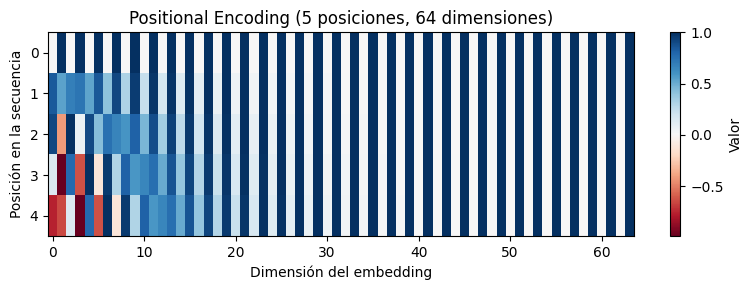

In [4]:
# Positional Encoding (sinusoidal)
# Self-attention es permutation-invariant: no sabe el orden de las palabras.
# PosEncoding le inyecta info de posición en el embedding.

def positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
    angles = pos * angle_rates

    pe = np.zeros_like(angles)
    pe[:, 0::2] = np.sin(angles[:, 0::2])
    pe[:, 1::2] = np.cos(angles[:, 1::2])
    return tf.cast(pe[np.newaxis, :, :], tf.float32)

# Visualizar positional encoding
seq_len, d_model = 5, 64
pe = positional_encoding(seq_len, d_model)[0]

plt.figure(figsize=(8, 3))
plt.imshow(pe.numpy(), cmap='RdBu', aspect='auto')
plt.colorbar(label='Valor')
plt.xlabel('Dimensión del embedding')
plt.ylabel('Posición en la secuencia')
plt.title('Positional Encoding (5 posiciones, 64 dimensiones)')
plt.tight_layout()
plt.show()

In [ ]:
# Self-Attention MANUAL (sin layers.MultiHeadAttention de Keras)
# 
# Q = Wq(x), K = Wk(x), V = Wv(x)
# scores = Q * K^T / sqrt(d_k)  ->  softmax  ->  att_weights * V
# Split en num_heads para atención multi-cabeza
#
# Ventaja sobre capa built-in de Keras:
#   - Más rápido para seq_len pequeña (sin overhead innecesario)
#   - Más didáctico: se ve exactamente el scaled dot-product
#   - Fácil de extraer att_weights para visualización

class ManualSelfAttention(layers.Layer):
    def __init__(self, embed_dim, num_heads=4, dropout_rate=0.1):
        super().__init__()
        assert embed_dim % num_heads == 0, "embed_dim debe ser divisible por num_heads"
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        self.Wq = layers.Dense(embed_dim, use_bias=False, name='Wq')
        self.Wk = layers.Dense(embed_dim, use_bias=False, name='Wk')
        self.Wv = layers.Dense(embed_dim, use_bias=False, name='Wv')
        self.Wo = layers.Dense(embed_dim, use_bias=False, name='Wo')
        self.dropout = layers.Dropout(dropout_rate)

    def call(self, x, return_attention=False):
        B = tf.shape(x)[0]
        T = tf.shape(x)[1]

        # Proyecciones lineales Q, K, V
        Q = self.Wq(x)                                # (B, T, embed_dim)
        K = self.Wk(x)                                # (B, T, embed_dim)
        V = self.Wv(x)                                # (B, T, embed_dim)

        # Split en múltiples heads
        Q = tf.reshape(Q, (B, T, self.num_heads, self.head_dim))
        K = tf.reshape(K, (B, T, self.num_heads, self.head_dim))
        V = tf.reshape(V, (B, T, self.num_heads, self.head_dim))

        # Transponer a (B, num_heads, T, head_dim) para matmul por head
        Q = tf.transpose(Q, [0, 2, 1, 3])
        K = tf.transpose(K, [0, 2, 1, 3])
        V = tf.transpose(V, [0, 2, 1, 3])

        # Scaled Dot-Product Attention
        # scores = Q * K^T / sqrt(d_k)
        scale = tf.sqrt(tf.cast(self.head_dim, tf.float32))
        scores = tf.matmul(Q, K, transpose_b=True) / scale   # (B, num_heads, T, T)
        att_weights = tf.nn.softmax(scores, axis=-1)
        att_weights = self.dropout(att_weights)

        # Context = att_weights * V
        context = tf.matmul(att_weights, V)                   # (B, num_heads, T, head_dim)

        # Concat heads: transponer y reshape
        context = tf.transpose(context, [0, 2, 1, 3])          # (B, T, num_heads, head_dim)
        context = tf.reshape(context, (B, T, self.num_heads * self.head_dim))

        # Proyección final de salida
        out = self.Wo(context)                                 # (B, T, embed_dim)

        if return_attention:
            # Promediar sobre heads para visualización
            att_avg = tf.reduce_mean(att_weights, axis=1)      # (B, T, T)
            return out, att_avg
        return out


class SelfAttentionWordPredictor(keras.Model):
    def __init__(self, embedding_layer, vocab_size, embed_dim, seq_len=5, num_heads=4):
        super().__init__()
        self.seq_len = seq_len
        self.embed_dim = embed_dim
        self.num_heads = num_heads

        self.embedding = embedding_layer
        self.pos_encoding = positional_encoding(seq_len, embed_dim)

        self.self_attn = ManualSelfAttention(embed_dim, num_heads, dropout_rate=0.1)
        self.layer_norm = layers.LayerNormalization(epsilon=1e-6)
        self.pool = layers.GlobalAveragePooling1D()
        self.out = layers.Dense(vocab_size, activation='softmax')

    def call(self, inputs, return_attention=False):
        x = self.embedding(inputs)
        x = x + self.pos_encoding
        x = tf.nn.dropout(x, rate=0.1)

        if return_attention:
            attn_output, attn_weights = self.self_attn(x, return_attention=True)
        else:
            attn_output = self.self_attn(x)
            attn_weights = None

        out = self.layer_norm(x + attn_output)
        pooled = self.pool(out)
        logits = self.out(pooled)

        if return_attention:
            return logits, attn_weights
        return logits

vocab_size = loader.target_embeddings.shape[0]
model = SelfAttentionWordPredictor(
    loader.embedding_layer, vocab_size, loader.embedding_dim,
    seq_len=5, num_heads=4
)

optimizer = keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.build((None, 5))
model.summary()

batch_size = 64
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(min(len(X_train), 2000)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

callbacks = [keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)]

history = model.fit(train_ds, validation_data=val_ds, epochs=100, verbose=1, callbacks=callbacks)

/home/eanorambuena/miniconda/envs/tfenv/lib/python3.12/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'self_attention_word_predictor', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "self_attention_word_predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pretrained_embedding            │ ?                      │       210,624 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ manual_self_attention           │ ?                      │   0 (unbuilt) │
│ (ManualSelfAttention)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ ?                      │   0 (unbuilt) │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 210,624 (822.75 KB)

 Trainable params: 210,624 (822.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.1026 - loss: 6.9231 - val_accuracy: 0.1032 - val_loss: 6.6754
Epoch 2/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.1060 - loss: 6.1964 - val_accuracy: 0.1030 - val_loss: 6.2454
Epoch 3/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.1186 - loss: 5.4173 - val_accuracy: 0.1116 - val_loss: 5.7458
Epoch 4/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.1468 - loss: 4.6020 - val_accuracy: 0.1230 - val_loss: 5.3123
Epoch 5/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.2072 - loss: 3.8767 - val_accuracy: 0.1207 - val_loss: 4.9904
Epoch 6/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.2836 - loss: 3.3006 - val_accuracy: 0.1427 - val_loss: 4.7162
Epoch 7/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.3523 - loss: 2.8753 - val_accuracy: 0.1734 - val_loss: 4.4566
Epoch 8/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.3989 - loss: 2.5618 - 

In [ ]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy (Self-Attention manual): {acc:.3f}')

def predict_next_word(context_words, top_n=5):
    context_ids = [loader.text_vocab[w] for w in context_words if w in loader.text_vocab]
    if len(context_ids) < 5:
        return []
    context_ids = np.array([context_ids[:5]], dtype=np.int32)
    probs = model.predict(context_ids, verbose=0)[0]
    top_indices = np.argsort(probs)[-top_n:][::-1]
    return [(loader.decode(idx), float(probs[idx])) for idx in top_indices]

sample_contexts = [
    ['london', 'bridge', 'river', 'city', 'center'],
    ['bank', 'of', 'england', 'is', 'located'],
    ['queen', 'of', 'england', 'lives', 'in']
]

for context in sample_contexts:
    preds = predict_next_word(context, top_n=5)
    if preds:
        print(f"Contexto {context} -> {preds}")

plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Self-Attention Manual - Training History')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Visualización: Heatmap de Self-Attention (ahora con att_weights reales de ManualSelfAttention)
# Cada celda (i,j) = cuánto "atiende" la palabra i a la palabra j

def plot_attention_heatmap(context_words, model):
    context_ids = [loader.text_vocab[w] for w in context_words if w in loader.text_vocab]
    if len(context_ids) < 5:
        context_ids = context_ids + [0] * (5 - len(context_ids))
    context_ids = np.array([context_ids[:5]], dtype=np.int32)

    _, attn_avg = model(context_ids, return_attention=True)
    attn_matrix = attn_avg[0].numpy()  # (5, 5)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    im = axes[0].imshow(attn_matrix, cmap='YlOrRd', vmin=0, vmax=1)
    axes[0].set_xticks(range(len(context_words)))
    axes[0].set_yticks(range(len(context_words)))
    axes[0].set_xticklabels(context_words, rotation=45, ha='right')
    axes[0].set_yticklabels(context_words)
    axes[0].set_title('Self-Attention (promedio sobre heads)')
    fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
    for i in range(5):
        for j in range(5):
            axes[0].text(j, i, f'{attn_matrix[i,j]:.2f}',
                       ha='center', va='center',
                       color='white' if attn_matrix[i,j] > 0.5 else 'black',
                       fontsize=9)

    # Atención recibida vs emitida
    attention_received = attn_matrix.sum(axis=0)
    attention_given = attn_matrix.sum(axis=1)
    x = np.arange(len(context_words))
    axes[1].bar(x - 0.15, attention_received, 0.3, label='Recibida', color='coral')
    axes[1].bar(x + 0.15, attention_given, 0.3, label='Emitida', color='steelblue')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(context_words, rotation=45, ha='right')
    axes[1].set_title('Balance de atención por palabra')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    idx_max_recv = np.argmax(attention_received)
    idx_max_given = np.argmax(attention_given)
    print(f"Palabra más atendida: '{context_words[idx_max_recv]}' (recibe {attention_received[idx_max_recv]:.2f})")
    print(f"Palabra que más atiende: '{context_words[idx_max_given]}' (emite {attention_given[idx_max_given]:.2f})")


plot_attention_heatmap(['bank', 'of', 'england', 'is', 'located'], model)

In [ ]:
# Comparar heatmaps para distintos contextos
contexts_to_compare = [
    ['london', 'bridge', 'river', 'city', 'center'],
    ['queen', 'of', 'england', 'lives', 'in'],
    ['big', 'ben', 'clock', 'tower', 'london'],
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, ctx in enumerate(contexts_to_compare):
    context_ids = [loader.text_vocab[w] for w in ctx if w in loader.text_vocab]
    if len(context_ids) < 5:
        context_ids = context_ids + [0] * (5 - len(context_ids))
    context_ids = np.array([context_ids[:5]], dtype=np.int32)

    _, attn_avg = model(context_ids, return_attention=True)
    attn_matrix = attn_avg[0].numpy()

    im = axes[idx].imshow(attn_matrix, cmap='YlOrRd', vmin=0, vmax=1)
    axes[idx].set_xticks(range(5))
    axes[idx].set_yticks(range(5))
    axes[idx].set_xticklabels(ctx, rotation=45, ha='right', fontsize=9)
    axes[idx].set_yticklabels(ctx, fontsize=9)
    axes[idx].set_title(f'Contexto: {" ".join(ctx)}', fontsize=10)
    fig.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)
    for i in range(5):
        for j in range(5):
            axes[idx].text(j, i, f'{attn_matrix[i,j]:.2f}',
                        ha='center', va='center',
                        color='white' if attn_matrix[i,j] > 0.5 else 'black',
                        fontsize=7)

plt.suptitle('Matrices de Self-Attention para diferentes contextos', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## Comparación completa

| Notebook | Modelo | Window | step | Test Accuracy |
|----------|--------|:-----:|:----:|:------------:|
| 18 | RNN vanilla | 5 | 1 | 0.403 |
| 19 | RNN + gradient clipping | 64 | 5 (original) | 0.105 |
| 19 | RNN + gradient clipping | 64 | 1 (corregido) | 0.420 |
| 20 | RNN + Bahdanau Attention | 5 | 1 | **0.575** |
| **21** | **Self-Attention manual** | **5** | **1** | **0.405** |
| **21_v3** | **Self-Attention (trainable emb)** | **5** | **1** | **?** |

**Evolución:**
- 18: RNN vanilla (0.403) — línea base
- 19: `step=5` original falló (0.105); corregido a `step=1` logra 0.420 (similar a 18)
- 20: Attention sobre RNN (0.575) — salto cualitativo
- **21: Self-attention manual (0.405) — no mejora a 18 para seq_len=5**

**Análisis:** Self-attention con 1 sola capa y seq_len=5 no supera a la RNN vanilla.
Para secuencias muy cortas, la RNN comprime igual de bien que la atención.
**21_v3:** embeddings entrenables para ver si desbloquea más capacidad.